In [2]:
import sys
sys.path.append("../scripts/")

In [3]:
import multiprocessing as mp
import warnings


import numpy as np
from scipy.stats import binned_statistic, binned_statistic_2d
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors
import matplotlib as mpl
from scipy.interpolate import interp1d
from scipy.signal import windows
from scipy import linalg
from nautilus import Prior, Sampler
import corner

In [4]:
Cs = sns.color_palette("colorblind")
Cp = sns.color_palette("Paired")

In [5]:
import niceplots
niceplots.initPlot()

In [6]:
from classy_wraper_for_m21cm import *
from specs import *
from meer21cm import PowerSpectrum
from meer21cm.power import get_modelpk_conv


# Compare model to simulations

In [7]:
z_func = interp1d(
    z_cen, z_count / dV_arr, kind="linear", bounds_error=False, fill_value=0
)

ps = PowerSpectrum(
        wproj=wcs,
        num_pix_x=num_pix_x,
        num_pix_y=num_pix_y,
        ra_range=ra_range,
        dec_range=dec_range,
        nu=nu_arr,
        discrete_source_dndz=z_func,
        tracer_bias_2=1.5,
        tracer_bias_1=1.5,
        mean_amp_1="average_hi_temp",
        omega_hi=5e-4,
        sigma_beam_ch=sigma_beam_new,
        sigma_v_1= 100, # in velocity units
        sigma_v_2= 100,
    )

ps.grid_scheme = "cic"
ps.taper_function = getattr(windows, window_name)

num_gal = int(ps.survey_volume * n_gal)
ps.num_discrete_source = num_gal
ps.W_HI = np.ones_like(ps.W_HI)
ps.w_HI = np.ones_like(ps.w_HI)

ps.trim_map_to_range()
# ps.trim_gal_to_range()
ps.downres_factor_transverse = 3
ps.downres_factor_radial = 6
ps.get_enclosing_box()

ps.weights_1 = ps.counts_in_box.astype('float')
dndz_box = ps.discrete_source_dndz(ps._box_voxel_redshift)
ps.weights_field_2 = dndz_box
ps.weights_grid_2 = ((dndz_box>0)*ps.counts_in_box).astype('float') # test

In [8]:
beam = ps.beam_attenuation()

ps.sampling_resol = [
    ps.pix_resol_in_mpc,
    ps.pix_resol_in_mpc,
    ps.los_resol_in_mpc,
]
pix = ps.map_sampling()

grid = ps.gridding_compensation()
T2 = grid**2 * pix * beam
# T2 = beam

In [9]:
data = np.load("../data/power_spectra_full_sims.npz")
k, P_HIxGal = data["kmode"], data["phixgal"]
kvec = ps.k_vec
mu = ps.mu_mode

In [10]:
kmask =  np.logical_and(k<0.20, k>0)
# kmask = np.logical_and(
#     kvec[0][:, None, None] > 0,
#     np.logical_and(
#         kvec[1][:, None] > 0,
#         kvec[2] > 0,
#     )
# )


kparr = k * ps.mu_mode
kperp = k * np.sqrt(np.clip(1 - ps.mu_mode**2,0,1))

kparr_bins = np.linspace(0, kparr[np.logical_and(kmask, kparr<0.20)].max(), 20)
kperp_bins = np.linspace(0, kperp[np.logical_and(kmask, kperp<0.6/np.sqrt(2))].max(), 8)[1:]


k_parr_bincenters = 0.5 * (kparr_bins[1:] + kparr_bins[:-1])
k_perp_bincenters = 0.5 * (kperp_bins[1:] + kperp_bins[:-1])

kpar = kparr[kmask]
kper = kperp[kmask]

bin_par = np.digitize(kpar, kparr_bins) - 1
bin_per = np.digitize(kper, kperp_bins) - 1

valid = (
    (bin_par >= 0) & (bin_par < len(kparr_bins)-1) &
    (bin_per >= 0) & (bin_per < len(kperp_bins)-1)
)

bin_par = bin_par[valid]
bin_per = bin_per[valid]

mode_indices = np.where(kmask)[0][valid]

nb_par = len(kparr_bins) - 1
nb_per = len(kperp_bins) - 1

bin_index = bin_par * nb_per + bin_per
Nbins = nb_par * nb_per
Nmodes = len(mode_indices)

B = np.zeros((Nbins, Nmodes))

for i, b in enumerate(bin_index):
    B[b, i] += 1.0

# normalize (mean per bin)
counts = B.sum(axis=1, keepdims=True)
B /= np.where(counts == 0, 1, counts)

In [11]:
counts[:, 0]

array([ 64., 116., 160., 192., 156.,  64.,  32.,  58.,  80.,  96.,  78.,
        32.,  64., 116., 160., 192., 156.,  64.,  32.,  58.,  80.,  96.,
        78.,  32.,  32.,  58.,  80.,  96.,  78.,  32.,  64., 116., 160.,
       192., 156.,  64.,  32.,  58.,  80.,  96.,  78.,  32.,  32.,  58.,
        80.,  96.,  78.,  32.,  64., 116., 160., 192., 156.,  64.,  32.,
        58.,  80.,  96.,  78.,  32.,  64., 116., 160., 192., 156.,  64.,
        32.,  58.,  80.,  96.,  78.,  32.,  32.,  58.,  80.,  96.,  78.,
        32.,  64., 116., 160., 192., 156.,  64.,  32.,  58.,  80.,  96.,
        78.,  32.,  32.,  58.,  80.,  96.,  78.,  32.,  64., 116., 160.,
       192., 156.,  64.,  32.,  58.,  80.,  96.,  78.,  32.,  32.,  58.,
        80.,  96.,  78.,  28.])

In [12]:
Pk_2d_Tg_sims = P_HIxGal[:, kmask][:, valid] @ B.T
Pk_2d_Tg_sims.shape

(500, 114)

In [13]:
fid_bao_pars = {
    "alpha_parr" :1,
    "alpha_perp" :1,
    "sigma_p" :ps.deltav_to_deltar(100), # Mpc
    "sigma_v" :ps.deltav_to_deltar(100), # Mpc
    "bias":1.5,
    "bias_2":1.5,
}

classcosmo = Class_cosmo_model({})
baocosmo = power_spectrum_from_baopars(classcosmo, fid_bao_pars)
Pk_3d_fid_mod = baocosmo.powerspectrum(k, ps.mu_mode, ps.z, which="both")
Pk_nw_3d_fid_mod = baocosmo.powerspectrum_nw(k, ps.mu_mode, ps.z, which="both")

{}


/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:482: RuntimeWarning: invalid value encountered in divide
  mu_prime = kparr_prime / k_prime
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:62: RuntimeWarning: divide by zero encountered in log
  logPk[..., i] = natural(np.log(k))
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:328: RuntimeWarning: divide by zero encountered in log
  Psl_peaks = natural(np.log(k))
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:337: RuntimeWarning: divide by zero encountered in log
  Psl_valleys = natural(np.log(k))


In [14]:
P_3d_Tg_mod = Pk_3d_fid_mod[1,...] * T2 * ps.average_hi_temp
P_3d_Tg_mod[~kmask] = 0.0 
P_3d_Tg_mod = get_modelpk_conv(P_3d_Tg_mod, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)
Pk_2d_Tg_mod = P_3d_Tg_mod[kmask][valid] @ B.T

P_nw_3d_Tg_mod = Pk_nw_3d_fid_mod[1,...] * T2 * ps.average_hi_temp
P_nw_3d_Tg_mod[~kmask] = 0.0 
P_nw_3d_Tg_mod = get_modelpk_conv(P_nw_3d_Tg_mod, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)
Pk_nw_2d_Tg_mod = P_nw_3d_Tg_mod[kmask][valid] @ B.T

In [15]:
Pk_plot_1 = Pk_2d_Tg_mod.reshape((*k_parr_bincenters.shape, *k_perp_bincenters.shape))
Pk_plot_2 = Pk_2d_Tg_sims.mean(0).reshape((*k_parr_bincenters.shape, *k_perp_bincenters.shape))

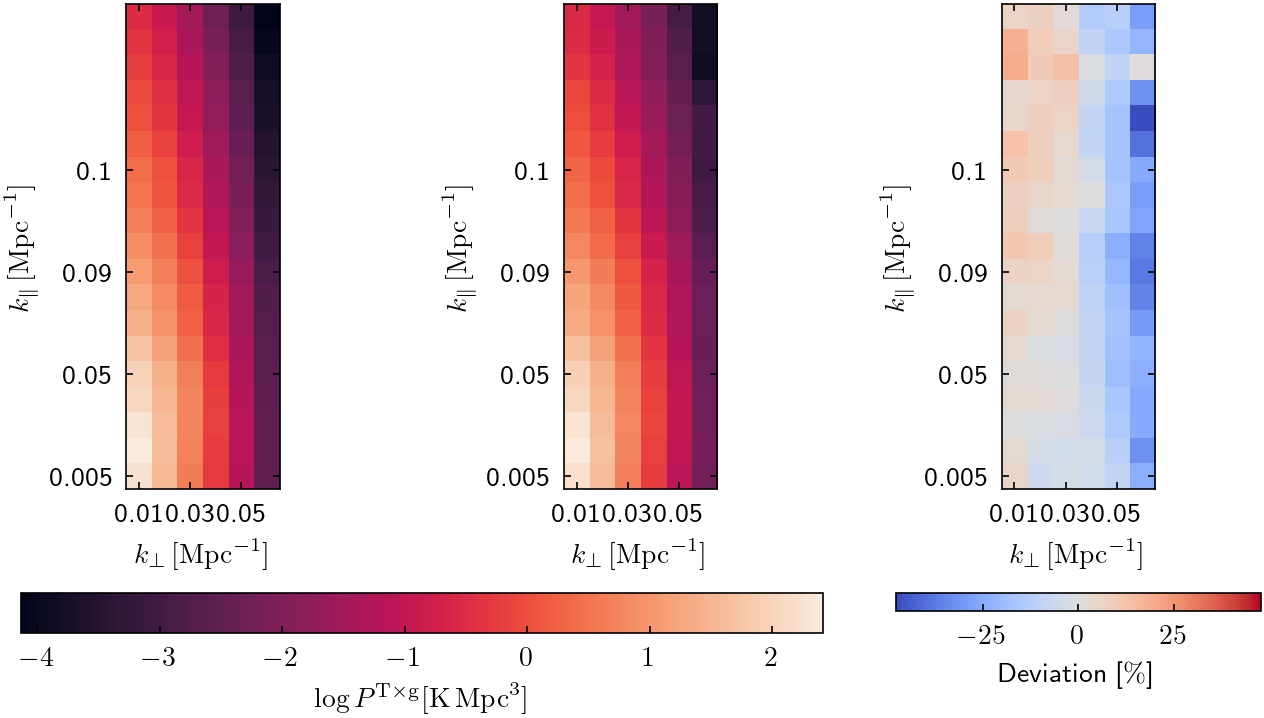

In [16]:
fw, fh = plt.rcParams['figure.figsize'] 
fig, axs = plt.subplots(1, 3, figsize=(2*fw, 1.5*fh))

# Define shared normalization for first two plots
vmin = min(np.log(Pk_plot_1).min(), np.log(Pk_plot_2).min())
vmax = max(np.log(Pk_plot_1).max(), np.log(Pk_plot_2).max())
norm = colors.Normalize(vmin=vmin, vmax=vmax)

# Plot images
im1 = axs[1].imshow(np.log(Pk_plot_2), norm=norm, origin="lower", cmap="rocket")
im0 = axs[0].imshow(np.log(Pk_plot_1), norm=norm, origin="lower", cmap="rocket")

# Difference plot (separate normalization)
diff = 100 * (Pk_plot_1 / Pk_plot_2 - 1)

rmax = np.max(np.abs(diff))

im2 = axs[2].imshow(diff, vmin=-rmax, vmax=rmax, cmap="coolwarm", origin="lower")
# im2 = axs[2].imshow(diff, vmin=-20, vmax=20, cmap="coolwarm", origin="lower")

# fig.subplots_adjust(wspace=)
# Shared colorbar for axs[0] and axs[1]
cbar1 = fig.colorbar(im0, ax=axs[:2], orientation="horizontal", label=r"$\log P^{\rm T \times g}[\mathrm{K}\,\mathrm{Mpc}^3]$")

# Separate colorbar for difference
cbar2 = fig.colorbar(im2, ax=axs[2], orientation="horizontal", label=r"Deviation [$\%$]")

for ax in axs:
    ax.set_xticks([0, 2, 4])
    ax.set_xticklabels(["{:.1}".format(k_perp_bincenters[i]) for i in [0, 2, 4]])
    ax.set_xlabel(r"$k_\perp\,[\mathrm{Mpc}^{-1}]$")
    ax.set_yticks([0, 4, 8, 12])
    ax.set_yticklabels(["{:.1}".format(k_parr_bincenters[i]) for i in [0, 4, 8, 12]])
    ax.set_ylabel(r"$k_\|\,[\mathrm{Mpc}^{-1}]$")

plt.show()

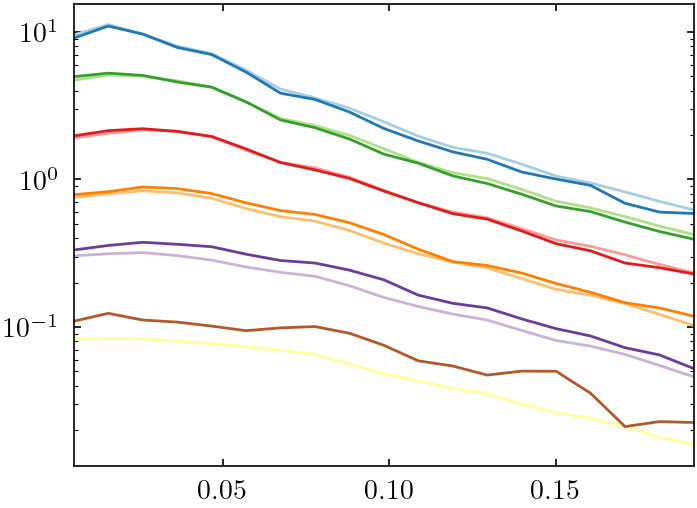

In [17]:
color = iter(Cp)
for p1, p2 in zip(Pk_plot_1.T, Pk_plot_2.T):
    plt.semilogy(k_parr_bincenters, p1, c=next(color))
    plt.semilogy(k_parr_bincenters, p2, c=next(color))

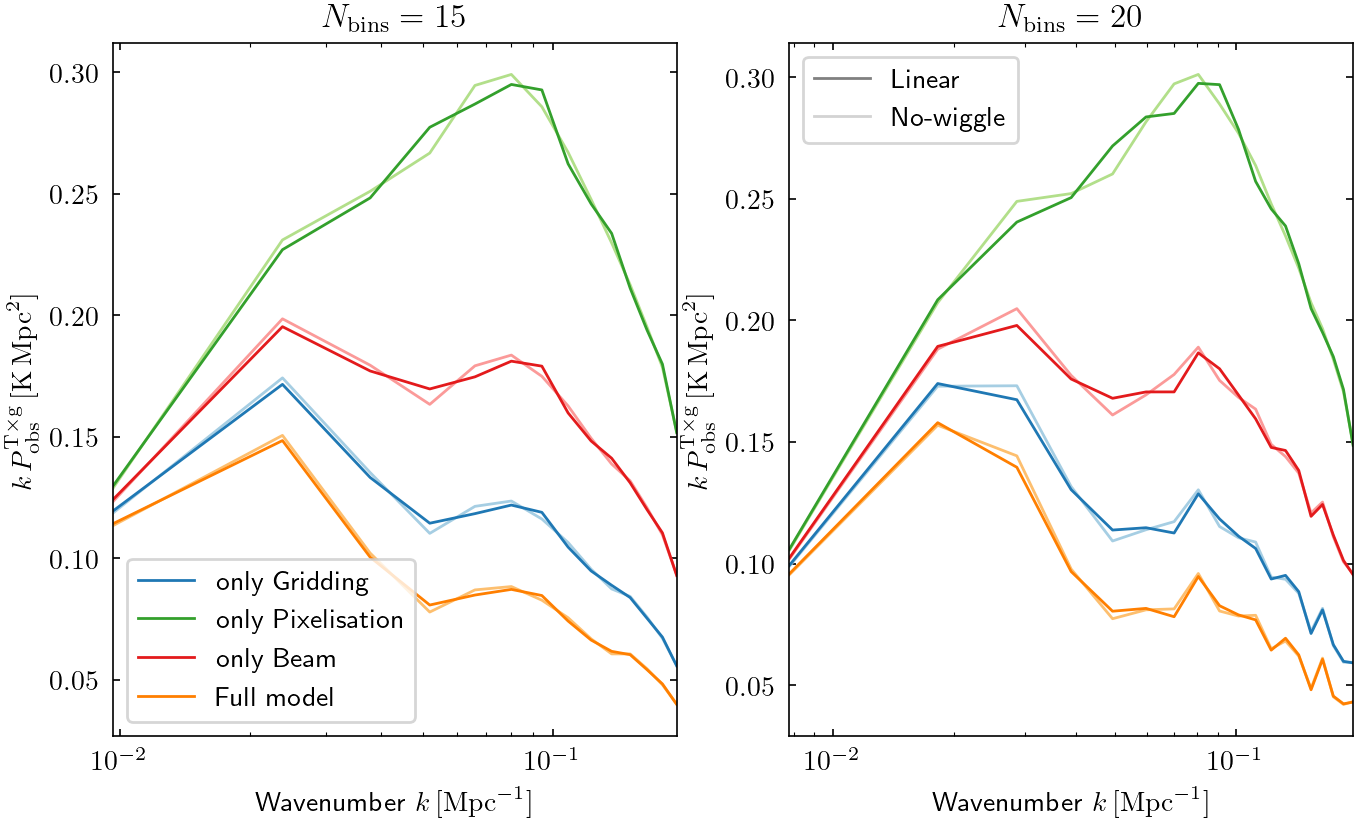

In [18]:
k_bins = np.linspace(k[kmask].min(), k[kmask].max(), 15)
k_low = 0.5 * (k_bins[1:] + k_bins[:-1])
N, _, bins = binned_statistic(k[kmask], [], "count", k_bins)
B_low = np.zeros((*bins.shape, *N.shape))
for i, b in enumerate(bins):
    B_low[i, b - 1] += 1
B_low *= 1/N

k_bins = np.linspace(k[kmask].min(), k[kmask].max(), 20)
k_high = 0.5 * (k_bins[1:] + k_bins[:-1])
N, _, bins = binned_statistic(k[kmask], [], "count", k_bins)
B_high = np.zeros((*bins.shape, *N.shape))
for i, b in enumerate(bins):
    B_high[i, b - 1] += 1
B_high *= 1/N

Ts = [grid**2, pix, beam, T2]
labels = ["only Gridding", "only Pixelisation", "only Beam", "Full model"]

color = iter(Cp)

fw, fh = plt.rcParams['figure.figsize'] 
fig, axs = plt.subplots(1, 2, figsize=(2*fw, 1.5*fh))
for T, l  in zip(Ts, labels):
    P_3d_Tgi = Pk_nw_3d_fid_mod[1,...] * T * ps.average_hi_temp
    P_3d_Tgi[~kmask] = 0.0 
    P_3d_Tgi = get_modelpk_conv(P_3d_Tgi, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)

    c = next(color)
    P_1d_Tgi = P_3d_Tgi[kmask] @ B_low
    axs[0].semilogx(k_low, k_low * P_1d_Tgi, c=c)

    P_1d_Tgi = P_3d_Tgi[kmask] @ B_high
    axs[1].semilogx(k_high, k_high * P_1d_Tgi, c=c)

    P_3d_Tgi = Pk_3d_fid_mod[1,...] * T * ps.average_hi_temp
    P_3d_Tgi[~kmask] = 0.0 
    P_3d_Tgi = get_modelpk_conv(P_3d_Tgi, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)

    c = next(color)
    P_1d_Tgi = P_3d_Tgi[kmask] @ B_low
    axs[0].semilogx(k_low, k_low * P_1d_Tgi, c=c, label=l)

    P_1d_Tgi = P_3d_Tgi[kmask] @ B_high
    axs[1].semilogx(k_high, k_high * P_1d_Tgi, c=c)

axs[0].legend()
for ax in axs:
    ax.set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
    ax.set_ylabel(r"$k\,P^{\rm T \times g}_{\rm obs}\,[\mathrm{K}\,\mathrm{Mpc}^{2}]$")
axs[0].set_title(r"$N_{\rm bins}=15$")
axs[1].set_title(r"$N_{\rm bins}=20$")

axs[1].plot([],[], c="grey", label="Linear")
axs[1].plot([],[], c="lightgrey", label="No-wiggle")
axs[1].legend()

In [19]:
k_bins = np.linspace(k[kmask].min(), k[kmask].max(), 15)
k_bincenters = 0.5 * (k_bins[1:] + k_bins[:-1])

N, _, bins = binned_statistic(k[kmask], [], "count", k_bins)
B1d = np.zeros((*bins.shape, *N.shape))
for i, b in enumerate(bins):
    B1d[i, b - 1] += 1
B1d *= 1/N

In [20]:
Pk_1d_Tg_sims = P_HIxGal[:, kmask] @ B1d
Nsims, Nk = Pk_1d_Tg_sims.shape

cov = 1 / (Nsims - 1) * np.einsum("ij, ik -> jk", Pk_1d_Tg_sims - Pk_1d_Tg_sims.mean(0), Pk_1d_Tg_sims - Pk_1d_Tg_sims.mean(0))
corr = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))

(-0.12, 0.12)

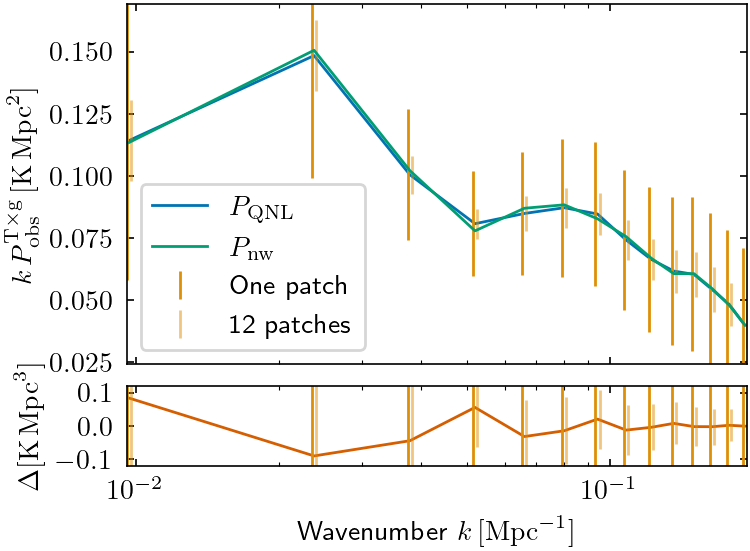

In [21]:
P_1d_Tg_mod = P_3d_Tg_mod[kmask] @ B1d
P_nw_1d_Tg_mod = P_nw_3d_Tg_mod[kmask] @ B1d

fig, axs = plt.subplots(2, 1, sharex=True, height_ratios=[9, 2])
fig.subplots_adjust(hspace=0.1)

color = iter(Cs)
# axs[0].errorbar(k_bincenters, k_bincenters * P_1d_Tg_mod, k_bincenters * np.diag(cov),c=next(color), label=r"$P_{\rm lin}$")

axs[0].semilogx(k_bincenters, k_bincenters * P_1d_Tg_mod, c=next(color), label=r"$P_{\rm QNL}$")

c = next(color)
axs[0].errorbar(k_bincenters * (0.99), k_bincenters * P_1d_Tg_mod, k_bincenters * np.sqrt(np.diag(cov)),c=c, ls="", label=r"One patch")
axs[0].errorbar(k_bincenters * (1.01), k_bincenters * P_1d_Tg_mod, k_bincenters * np.sqrt(np.diag(cov) / 12),c=c, alpha=0.5, ls="", label=r"12 patches")

axs[0].semilogx(k_bincenters, k_bincenters *P_nw_1d_Tg_mod, c=next(color), label=r"$P_{\rm nw}$")

axs[1].semilogx(k_bincenters, (P_1d_Tg_mod - P_nw_1d_Tg_mod), c=next(color))

axs[1].errorbar(k_bincenters * (0.99), (P_1d_Tg_mod - P_nw_1d_Tg_mod), np.sqrt(np.diag(cov)),c=c, ls="", label=r"One patch")
axs[1].errorbar(k_bincenters * (1.01), (P_1d_Tg_mod - P_nw_1d_Tg_mod), np.sqrt(np.diag(cov) / 12),c=c, alpha=0.5, ls="", label=r"12 patches")

axs[1].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
axs[0].set_ylabel(r"$k\,P^{\rm T \times g}_{\rm obs}\,[\mathrm{K}\,\mathrm{Mpc}^{2}]$")
axs[1].set_ylabel(r"$\Delta [\mathrm{K}\,\mathrm{Mpc}^{3}]$")
axs[0].legend(loc="lower left")

axs[0].set_ylim((0.024410034233877095, 0.1692694178863304))
axs[1].set_ylim((-0.12, 0.12))


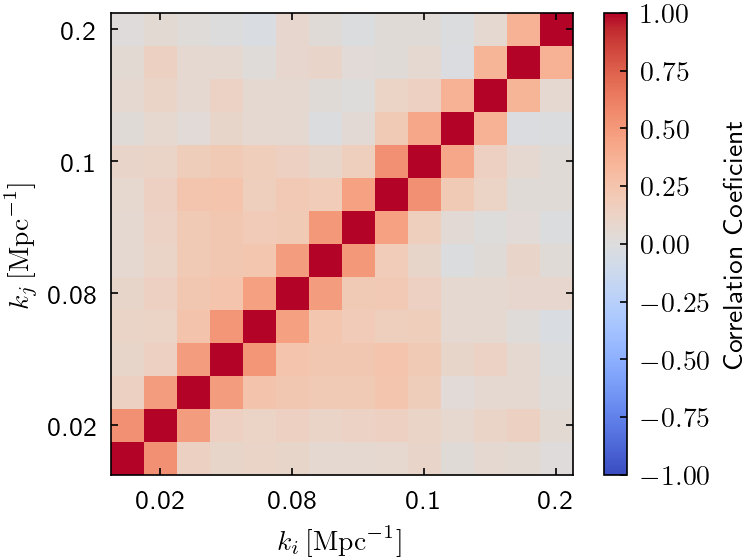

In [22]:
plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm", origin="lower")

ticks = [1 , 5, 9, 13]
plt.xticks(ticks, ["{:.1}".format(k_bincenters[i]) for i in ticks])
plt.yticks(ticks, ["{:.1}".format(k_bincenters[i]) for i in ticks])
plt.xlabel(r"$k_i\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$k_j\,[\mathrm{Mpc}^{-1}]$")
plt.colorbar(label=r"Correlation Coeficient")

## Quick Plots for 2D

In [23]:
Pk_1d_Tg_sims_rs = ps.average_hi_temp**-1 * P_HIxGal[:, kmask] @ B1d
Pk_1d_TT_sims_rs = ps.average_hi_temp**-2 * data["phi"][:, kmask] @ B1d
Pk_1d_sims_rs = np.concatenate((Pk_1d_TT_sims_rs, Pk_1d_Tg_sims_rs), axis=-1)


Nsims, Nk = Pk_1d_Tg_sims.shape

cov_2t = 1 / (Nsims - 1) * np.einsum("ij, ik -> jk", Pk_1d_sims_rs - Pk_1d_sims_rs.mean(0), Pk_1d_sims_rs - Pk_1d_sims_rs.mean(0))
corr = cov_2t / np.sqrt(np.outer(np.diag(cov_2t), np.diag(cov_2t)))


Text(0, 0.5, '$k\\,P_{\\rm Tg}\\,[T_{\\rm avg}\\,\\mathrm{Mpc}^2]$')

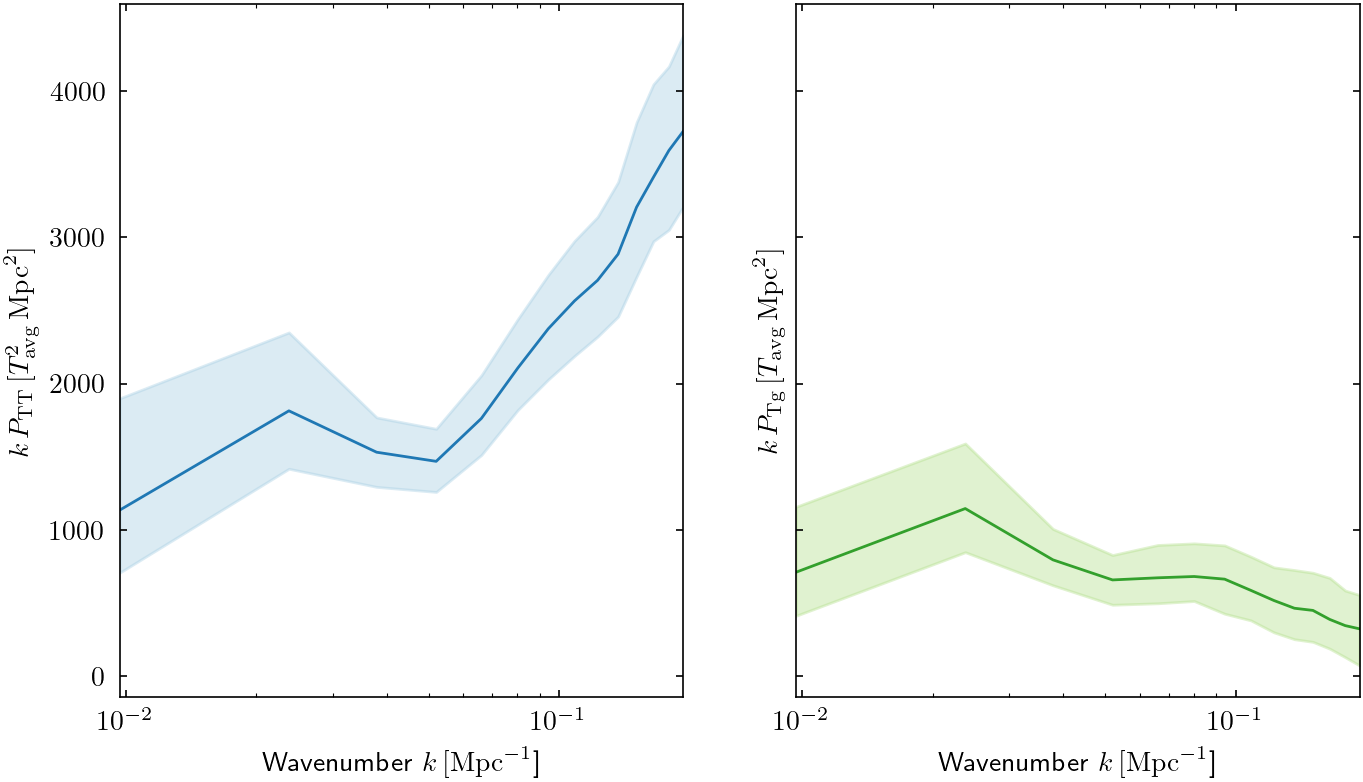

In [25]:
color = iter(Cp)

fw, fh = plt.rcParams['figure.figsize'] 
fig, axs = plt.subplots(1, 2, figsize=(2*fw, 1.5*fh), sharey=True)

TTm, TT, TTp = np.percentile(Pk_1d_TT_sims_rs, [16, 50, 84], axis=0)
axs[0].fill_between(k_bincenters, k_bincenters * TTm, k_bincenters * TTp, color=next(color), alpha=0.4)
axs[0].semilogx(k_bincenters, k_bincenters * TT, c=next(color))
axs[0].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}$]")
axs[0].set_ylabel(r"$k\,P_{\rm TT}\,[T^2_{\rm avg}\,\mathrm{Mpc}^2]$")

TTm, TT, TTp = np.percentile(Pk_1d_Tg_sims_rs, [16, 50, 84], axis=0)
axs[1].fill_between(k_bincenters, k_bincenters * TTm, k_bincenters * TTp, color=next(color), alpha=0.4)
axs[1].semilogx(k_bincenters, k_bincenters * TT, c=next(color))
axs[1].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}$]")
axs[1].set_ylabel(r"$k\,P_{\rm Tg}\,[T_{\rm avg}\,\mathrm{Mpc}^2]$")


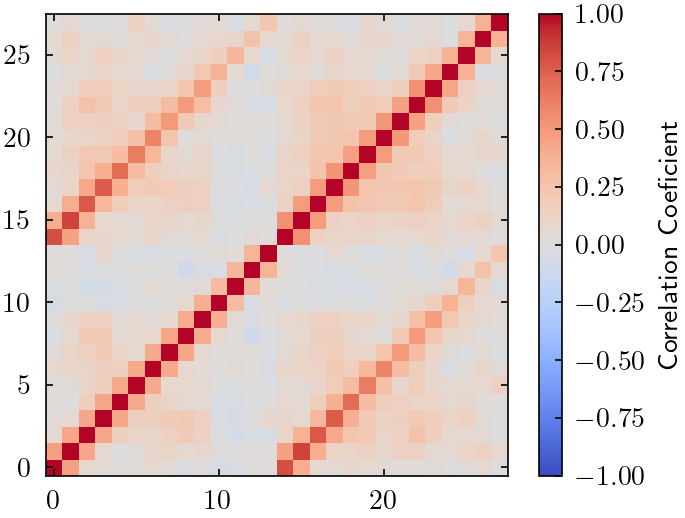

In [37]:
plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm", origin="lower")

# ticks = [1 , 5, 9, 13]
# plt.xticks(ticks, ["{:.1}".format(k_bincenters[i]) for i in ticks])
# plt.yticks(ticks, ["{:.1}".format(k_bincenters[i]) for i in ticks])
# plt.xlabel(r"$k_i\,[\mathrm{Mpc}^{-1}]$")
# plt.ylabel(r"$k_j\,[\mathrm{Mpc}^{-1}]$")
plt.colorbar(label=r"Correlation Coeficient")

# Test AP effect on 1D power spectrum

/tmp/ipykernel_9122/2221966746.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("coolwarm")
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:482: RuntimeWarning: invalid value encountered in divide
  mu_prime = kparr_prime / k_prime
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:62: RuntimeWarning: divide by zero encountered in log
  logPk[..., i] = natural(np.log(k))
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:328: RuntimeWarning: divide by zero encountered in log
  Psl_peaks = natural(np.log(k))
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:337: 

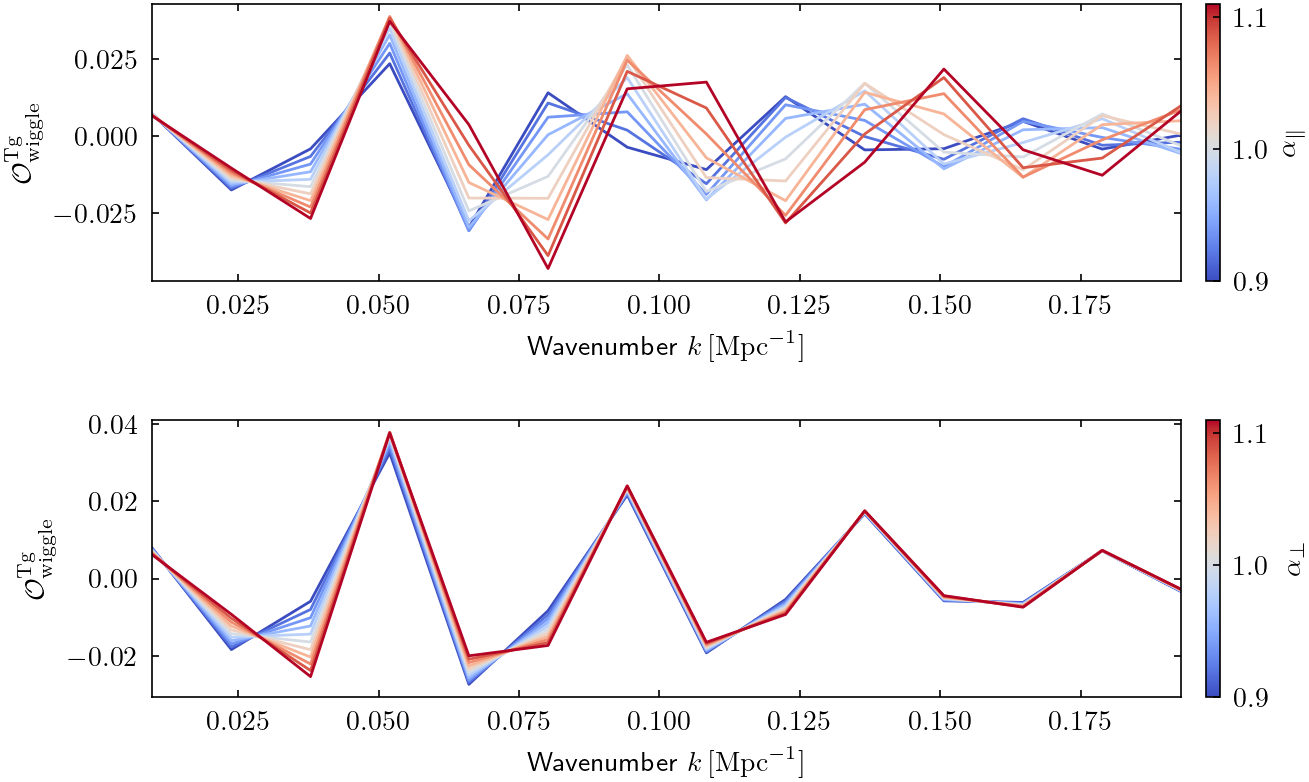

In [38]:
alpha_parr = np.geomspace(0.9, 1.11, num=11)
alpha_perp = np.geomspace(0.9, 1.11, num=11)

cmap = mpl.cm.get_cmap("coolwarm")
norm_parr = mpl.colors.Normalize(vmin=alpha_parr.min(), vmax=alpha_parr.max())
norm_perp = mpl.colors.Normalize(vmin=alpha_perp.min(), vmax=alpha_perp.max())

fw, fh = plt.rcParams['figure.figsize'] 
fig, axes = plt.subplots(2, 1, figsize=(2*fw, 1.5*fh))

for ai in alpha_parr:
    bao_pars = fid_bao_pars.copy()
    bao_pars["alpha_parr"] = ai
    baocosmo = power_spectrum_from_baopars(classcosmo, bao_pars, desi_like_bao=True)
    
    # wiggle
    Pk_fid = baocosmo.powerspectrum(k, ps.mu_mode, ps.z, which="both")
    P = Pk_fid[1,...] * T2 * ps.average_hi_temp 
    P[~kmask] = 0.0
    P = get_modelpk_conv(P, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)
    P1d = P[kmask] @ B1d

    # no-wiggle
    Pk_fid = baocosmo.powerspectrum_nw(k, ps.mu_mode, ps.z, which="both")
    P = Pk_fid[1,...] * T2 * ps.average_hi_temp
    P[~kmask] = 0.0
    P = get_modelpk_conv(P, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)
    P1d_nw = P[kmask] @ B1d

    axes[0].plot(
        k_bincenters,
        P1d / P1d_nw - 1,
        color=cmap(norm_parr(ai))
    )
axes[0].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
axes[0].set_ylabel(r"$\mathcal{O}_{\rm wiggle}^{\rm Tg}$")

for ai in alpha_perp:
    bao_pars = fid_bao_pars.copy()
    bao_pars["alpha_perp"] = ai
    baocosmo = power_spectrum_from_baopars(classcosmo, bao_pars, desi_like_bao=True)
    
    # wiggle
    Pk_fid = baocosmo.powerspectrum(k, ps.mu_mode, ps.z, which="both")
    P = Pk_fid[1,...] * T2 * ps.average_hi_temp
    P[~kmask] = 0.0
    P = get_modelpk_conv(P, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)
    P1d = P[kmask] @ B1d

    # no-wiggle
    Pk_fid = baocosmo.powerspectrum_nw(k, ps.mu_mode, ps.z, which="both")
    P = Pk_fid[1,...] * T2 * ps.average_hi_temp
    P[~kmask] = 0.0
    P = get_modelpk_conv(P, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)
    P1d_nw = P[kmask] @ B1d

    axes[1].plot(
        k_bincenters,
        P1d / P1d_nw - 1,
        color=cmap(norm_perp(ai))
    )
axes[1].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
axes[1].set_ylabel(r"$\mathcal{O}_{\rm wiggle}^{\rm Tg}$")

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_parr)
sm.set_array([])
fig.subplots_adjust(hspace= 0.5)
cbar = fig.colorbar(sm, ax=axes[0], location='right', pad=0.02)
cbar.set_label(r'$\alpha_{\parallel}$')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_perp)
sm.set_array([])
fig.subplots_adjust(hspace= 0.5)
cbar = fig.colorbar(sm, ax=axes[1], location='right', pad=0.02)
cbar.set_label(r'$\alpha_{\perp}$')


/tmp/ipykernel_9122/3293960955.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("coolwarm")


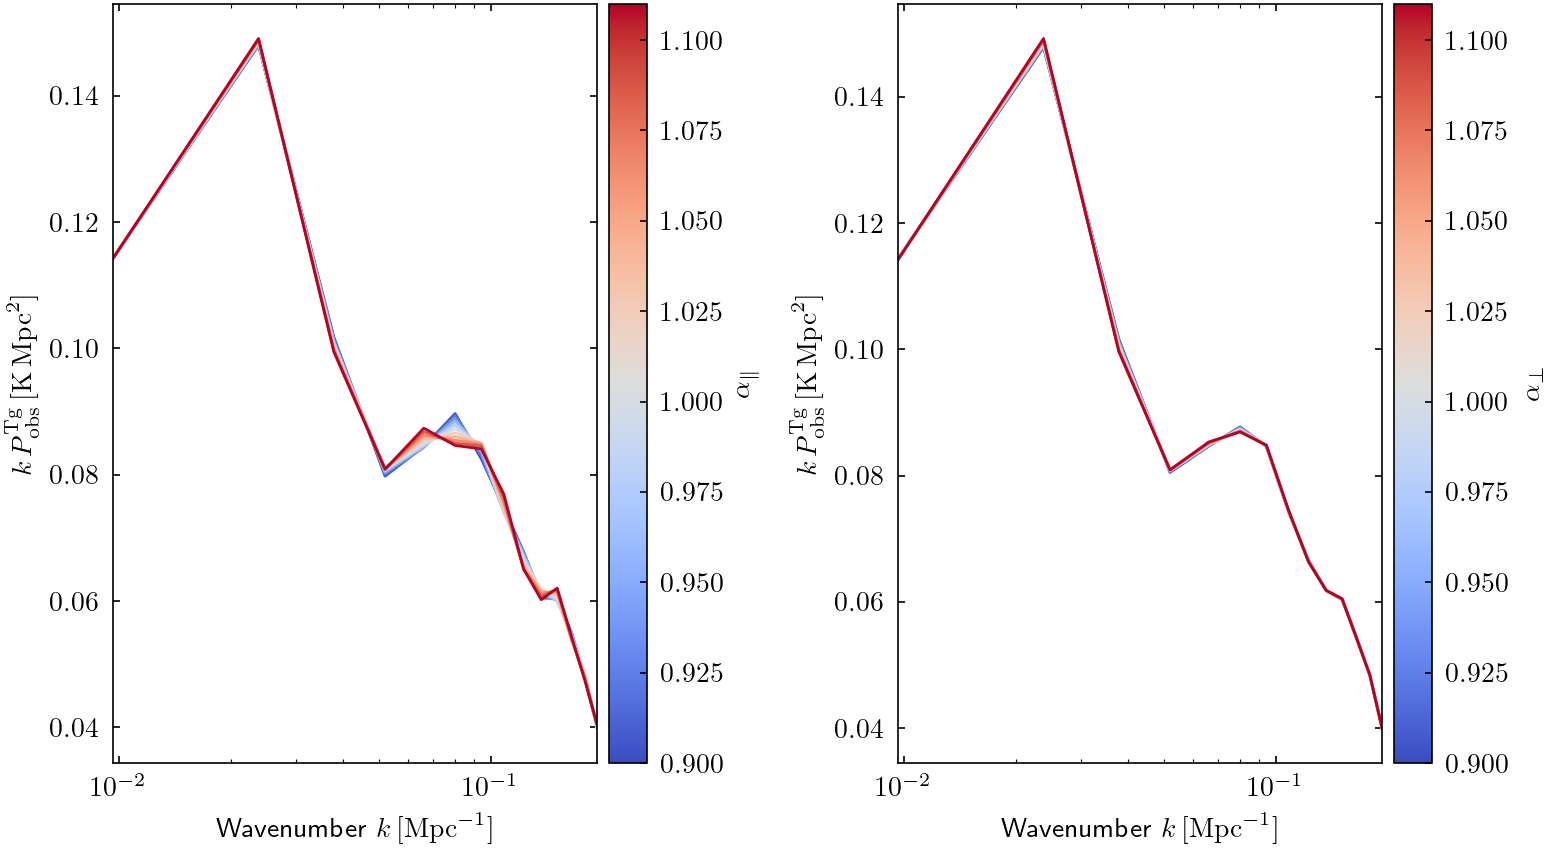

In [39]:
alpha_parr = np.geomspace(0.9, 1.11, num=11)
alpha_perp = np.geomspace(0.9, 1.11, num=11)

cmap = mpl.cm.get_cmap("coolwarm")
norm_parr = mpl.colors.Normalize(vmin=alpha_parr.min(), vmax=alpha_parr.max())
norm_perp = mpl.colors.Normalize(vmin=alpha_perp.min(), vmax=alpha_perp.max())

fw, fh = plt.rcParams['figure.figsize'] 
fig, axes = plt.subplots(1, 2, figsize=(2*fw, 1.5*fh))

for ai in alpha_parr:
    bao_pars = fid_bao_pars.copy()
    bao_pars["alpha_parr"] = ai
    baocosmo = power_spectrum_from_baopars(classcosmo, bao_pars, desi_like_bao=True)
    
    # wiggle
    Pk_fid = baocosmo.powerspectrum(k, ps.mu_mode, ps.z, which="both")
    P = Pk_fid[1,...] * T2 * ps.average_hi_temp 
    P[~kmask] = 0.0
    P = get_modelpk_conv(P, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)
    P1d = P[kmask] @ B1d

    axes[0].semilogx(
        k_bincenters,
        k_bincenters * P1d,
        color=cmap(norm_parr(ai))
    )
axes[0].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
axes[0].set_ylabel(r"$k\,P_{\rm obs}^{\rm Tg}\,[\mathrm{K}\,\mathrm{Mpc}^2]$")

for ai in alpha_perp:
    bao_pars = fid_bao_pars.copy()
    bao_pars["alpha_perp"] = ai
    baocosmo = power_spectrum_from_baopars(classcosmo, bao_pars, desi_like_bao=True)
    
    # wiggle
    Pk_fid = baocosmo.powerspectrum(k, ps.mu_mode, ps.z, which="both")
    P = Pk_fid[1,...] * T2 * ps.average_hi_temp
    P[~kmask] = 0.0
    P = get_modelpk_conv(P, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)
    P1d = P[kmask] @ B1d

    axes[1].semilogx(
        k_bincenters,
        k_bincenters * P1d,
        color=cmap(norm_perp(ai))
    )
axes[1].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
axes[1].set_ylabel(r"$k\,P_{\rm obs}^{\rm Tg}\,[\mathrm{K}\,\mathrm{Mpc}^2]$")

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_parr)
sm.set_array([])
fig.subplots_adjust(hspace= 0.5)
cbar = fig.colorbar(sm, ax=axes[0], location='right', pad=0.02)
cbar.set_label(r'$\alpha_{\parallel}$')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_perp)
sm.set_array([])
fig.subplots_adjust(hspace= 0.5)
cbar = fig.colorbar(sm, ax=axes[1], location='right', pad=0.02)
cbar.set_label(r'$\alpha_{\perp}$')
# fig.suptitle(r"DON'T Rescale $P_{\rm nw}$")
plt.tight_layout()


/tmp/ipykernel_15332/3238086501.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("coolwarm")
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:62: RuntimeWarning: divide by zero encountered in log
  logPk[..., i] = natural(np.log(k))
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:328: RuntimeWarning: divide by zero encountered in log
  Psl_peaks = natural(np.log(k))
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:337: RuntimeWarning: divide by zero encountered in log
  Psl_valleys = natural(np.log(k))


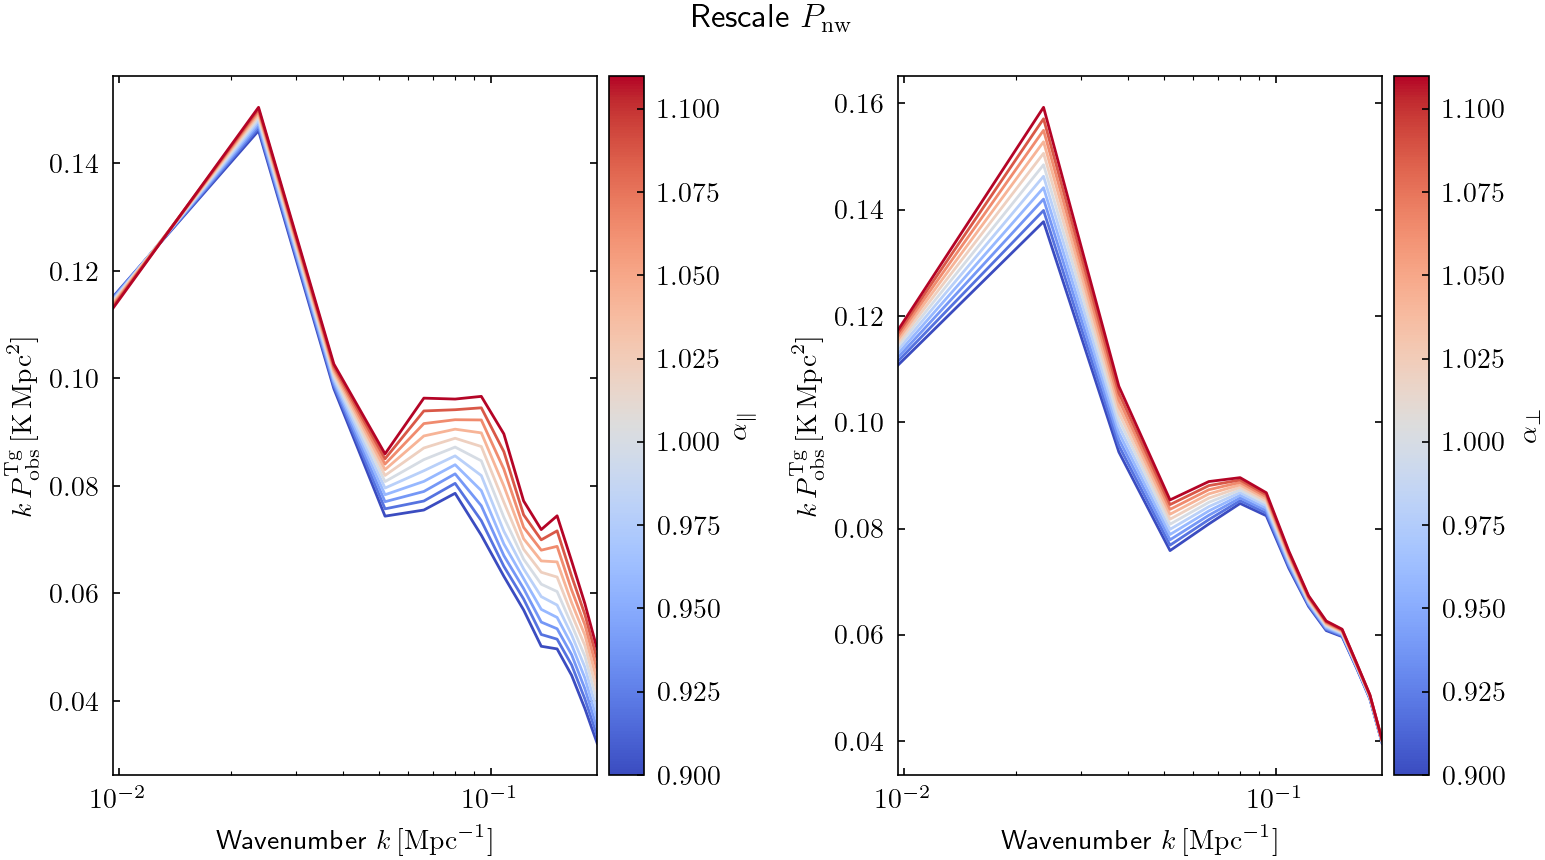

In [34]:
alpha_parr = np.geomspace(0.9, 1.11, num=11)
alpha_perp = np.geomspace(0.9, 1.11, num=11)

cmap = mpl.cm.get_cmap("coolwarm")
norm_parr = mpl.colors.Normalize(vmin=alpha_parr.min(), vmax=alpha_parr.max())
norm_perp = mpl.colors.Normalize(vmin=alpha_perp.min(), vmax=alpha_perp.max())

fw, fh = plt.rcParams['figure.figsize'] 
fig, axes = plt.subplots(1, 2, figsize=(2*fw, 1.5*fh))

for ai in alpha_parr:
    bao_pars = fid_bao_pars.copy()
    bao_pars["alpha_parr"] = ai
    baocosmo = power_spectrum_from_baopars(classcosmo, bao_pars)
    
    # wiggle
    Pk_fid = baocosmo.powerspectrum(k, ps.mu_mode, ps.z, which="both")
    P = Pk_fid[1,...] * T2 * ps.average_hi_temp 
    P[~kmask] = 0.0
    P = get_modelpk_conv(P, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)
    P1d = P[kmask] @ B1d

    axes[0].semilogx(
        k_bincenters,
        k_bincenters * P1d * ai,
        color=cmap(norm_parr(ai))
    )
axes[0].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
axes[0].set_ylabel(r"$k\,P_{\rm obs}^{\rm Tg}\,[\mathrm{K}\,\mathrm{Mpc}^2]$")

for ai in alpha_perp:
    bao_pars = fid_bao_pars.copy()
    bao_pars["alpha_perp"] = ai
    baocosmo = power_spectrum_from_baopars(classcosmo, bao_pars)
    
    # wiggle
    Pk_fid = baocosmo.powerspectrum(k, ps.mu_mode, ps.z, which="both")
    P = Pk_fid[1,...] * T2 * ps.average_hi_temp
    P[~kmask] = 0.0
    P = get_modelpk_conv(P, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)
    P1d = P[kmask] @ B1d

    axes[1].semilogx(
        k_bincenters,
        k_bincenters * P1d * ai**2,
        color=cmap(norm_perp(ai))
    )
axes[1].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
axes[1].set_ylabel(r"$k\,P_{\rm obs}^{\rm Tg}\,[\mathrm{K}\,\mathrm{Mpc}^2]$")

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_parr)
sm.set_array([])
fig.subplots_adjust(hspace= 0.5)
cbar = fig.colorbar(sm, ax=axes[0], location='right', pad=0.02)
cbar.set_label(r'$\alpha_{\parallel}$')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_perp)
sm.set_array([])
fig.subplots_adjust(hspace= 0.5)
cbar = fig.colorbar(sm, ax=axes[1], location='right', pad=0.02)
cbar.set_label(r'$\alpha_{\perp}$')
fig.suptitle(r"Rescale $P_{\rm nw}$")
plt.tight_layout()


/tmp/ipykernel_16757/3106624395.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("coolwarm")
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:482: RuntimeWarning: invalid value encountered in divide
  mu_prime = kparr_prime / k_prime


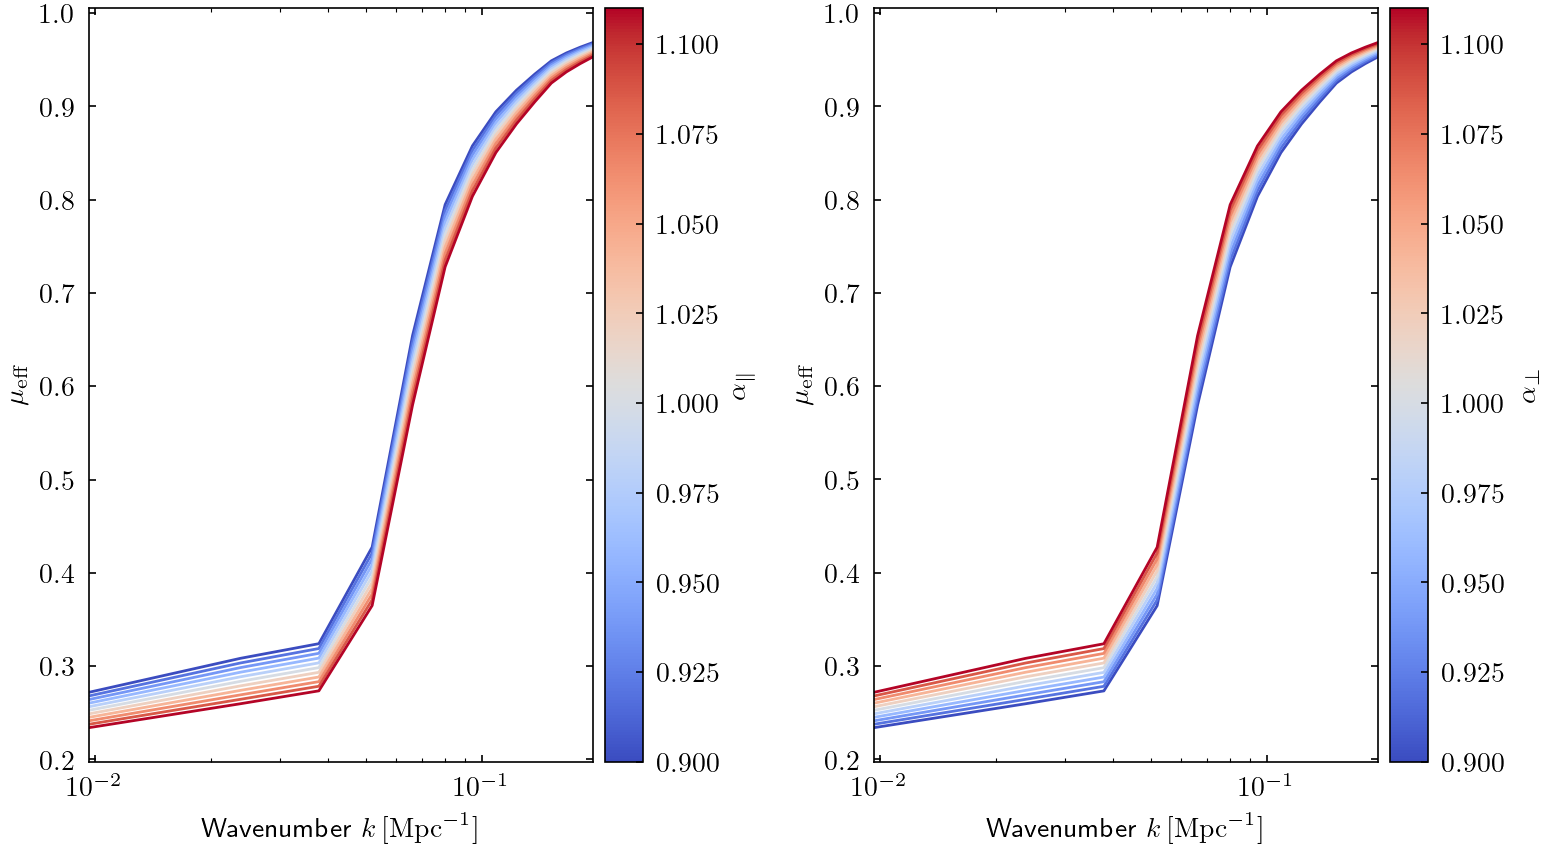

In [26]:
alpha_parr = np.geomspace(0.9, 1.11, num=11)
alpha_perp = np.geomspace(0.9, 1.11, num=11)

cmap = mpl.cm.get_cmap("coolwarm")
norm_parr = mpl.colors.Normalize(vmin=alpha_parr.min(), vmax=alpha_parr.max())
norm_perp = mpl.colors.Normalize(vmin=alpha_perp.min(), vmax=alpha_perp.max())

fw, fh = plt.rcParams['figure.figsize'] 
fig, axes = plt.subplots(1, 2, figsize=(2*fw, 1.5*fh))

for ai in alpha_parr:
    bao_pars = fid_bao_pars.copy()
    bao_pars["alpha_parr"] = ai
    baocosmo = power_spectrum_from_baopars(classcosmo, bao_pars)
    
    _, muprime = baocosmo.convert_modes(k, ps.mu_mode)

    axes[0].semilogx(
        k_bincenters,
        muprime[kmask]**2 @ B1d,
        color=cmap(norm_parr(ai))
    )
axes[0].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
axes[0].set_ylabel(r"$\mu_{\rm eff}$")

for ai in alpha_perp:
    bao_pars = fid_bao_pars.copy()
    bao_pars["alpha_perp"] = ai
    baocosmo = power_spectrum_from_baopars(classcosmo, bao_pars)
    
    _, muprime = baocosmo.convert_modes(k, ps.mu_mode)

    axes[1].semilogx(
        k_bincenters,
        muprime[kmask]**2 @ B1d,
        color=cmap(norm_parr(ai))
    )
axes[1].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
axes[1].set_ylabel(r"$\mu_{\rm eff}$")


sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_parr)
sm.set_array([])
fig.subplots_adjust(hspace= 0.5)
cbar = fig.colorbar(sm, ax=axes[0], location='right', pad=0.02)
cbar.set_label(r'$\alpha_{\parallel}$')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_perp)
sm.set_array([])
fig.subplots_adjust(hspace= 0.5)
cbar = fig.colorbar(sm, ax=axes[1], location='right', pad=0.02)
cbar.set_label(r'$\alpha_{\perp}$')
plt.tight_layout()


# Test BAO sampling pipeline

In [63]:
Pk_wiggle_1d_Tg_fid = P_1d_Tg_mod - P_nw_1d_Tg_mod

def loglike(pars):
    bao_pars = fid_bao_pars.copy()
    bao_pars.update(pars)
    
    baocosmo = power_spectrum_from_baopars(classcosmo, bao_pars)
    Pk_3d_fid_true = baocosmo.powerspectrum(k, ps.mu_mode, ps.z, which="both")
    Pk_nw_3d_fid_true = baocosmo.powerspectrum_nw(k, ps.mu_mode, ps.z, which="both")

    P_3d_Tg_true = Pk_3d_fid_true[1,...] * T2 * ps.average_hi_temp
    P_3d_Tg_true[~kmask] = 0.0 
    P_3d_Tg_true = get_modelpk_conv(P_3d_Tg_true, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)

    P_nw_3d_Tg_true = Pk_nw_3d_fid_true[1,...] * T2 * ps.average_hi_temp
    P_nw_3d_Tg_true[~kmask] = 0.0 
    P_nw_3d_Tg_true = get_modelpk_conv(P_nw_3d_Tg_true, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)
    Pk_wiggle_1d_Tg_true = (P_3d_Tg_true - P_nw_3d_Tg_true)[kmask] @ B1d

    fudge = 1 / 120
    Delta = Pk_wiggle_1d_Tg_true - Pk_wiggle_1d_Tg_fid
    chi2 = np.einsum("i, ij, j", Delta, linalg.inv(cov * fudge), Delta)
    return -0.5 * chi2

In [ ]:
loglike({"alpha_parr":4})

-7.529209670959988

In [ ]:
prior = Prior()
prior.add_parameter("bias", (0.1, 10))
prior.add_parameter("bias_2", (0.1, 10))
# prior.add_parameter("sigma_p", (1, 10)) # our scalecuts are very conservative rn but probably we still need to vary this
prior.add_parameter("alpha_perp", (0.1, 5))
prior.add_parameter("alpha_parr", (0.1, 5))

sampler = Sampler(prior, loglike, n_live=2000, pool=12, filepath="../data/chain_v1_1D_Tg_perfect_bb.hdf5")

/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:481: RuntimeWarning: invalid value encountered in divide
  mu_prime = kparr_prime / k_prime
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:481: RuntimeWarning: invalid value encountered in divide
  mu_prime = kparr_prime / k_prime
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:481: RuntimeWarning: invalid value encountered in divide
  mu_prime = kparr_prime / k_prime
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:481: RuntimeWarning: invalid value encountered in divide
  mu_prime = kparr_prime / k_prime
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:481: RuntimeWarning: invalid value encountered in divide
  mu_prime = kparr_prime / k_prime
/home

In [70]:
sampler.run(verbose=True)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 15     | 1        | 4        | 33804    | N/A    | 20261 | -5.93    


True

hello


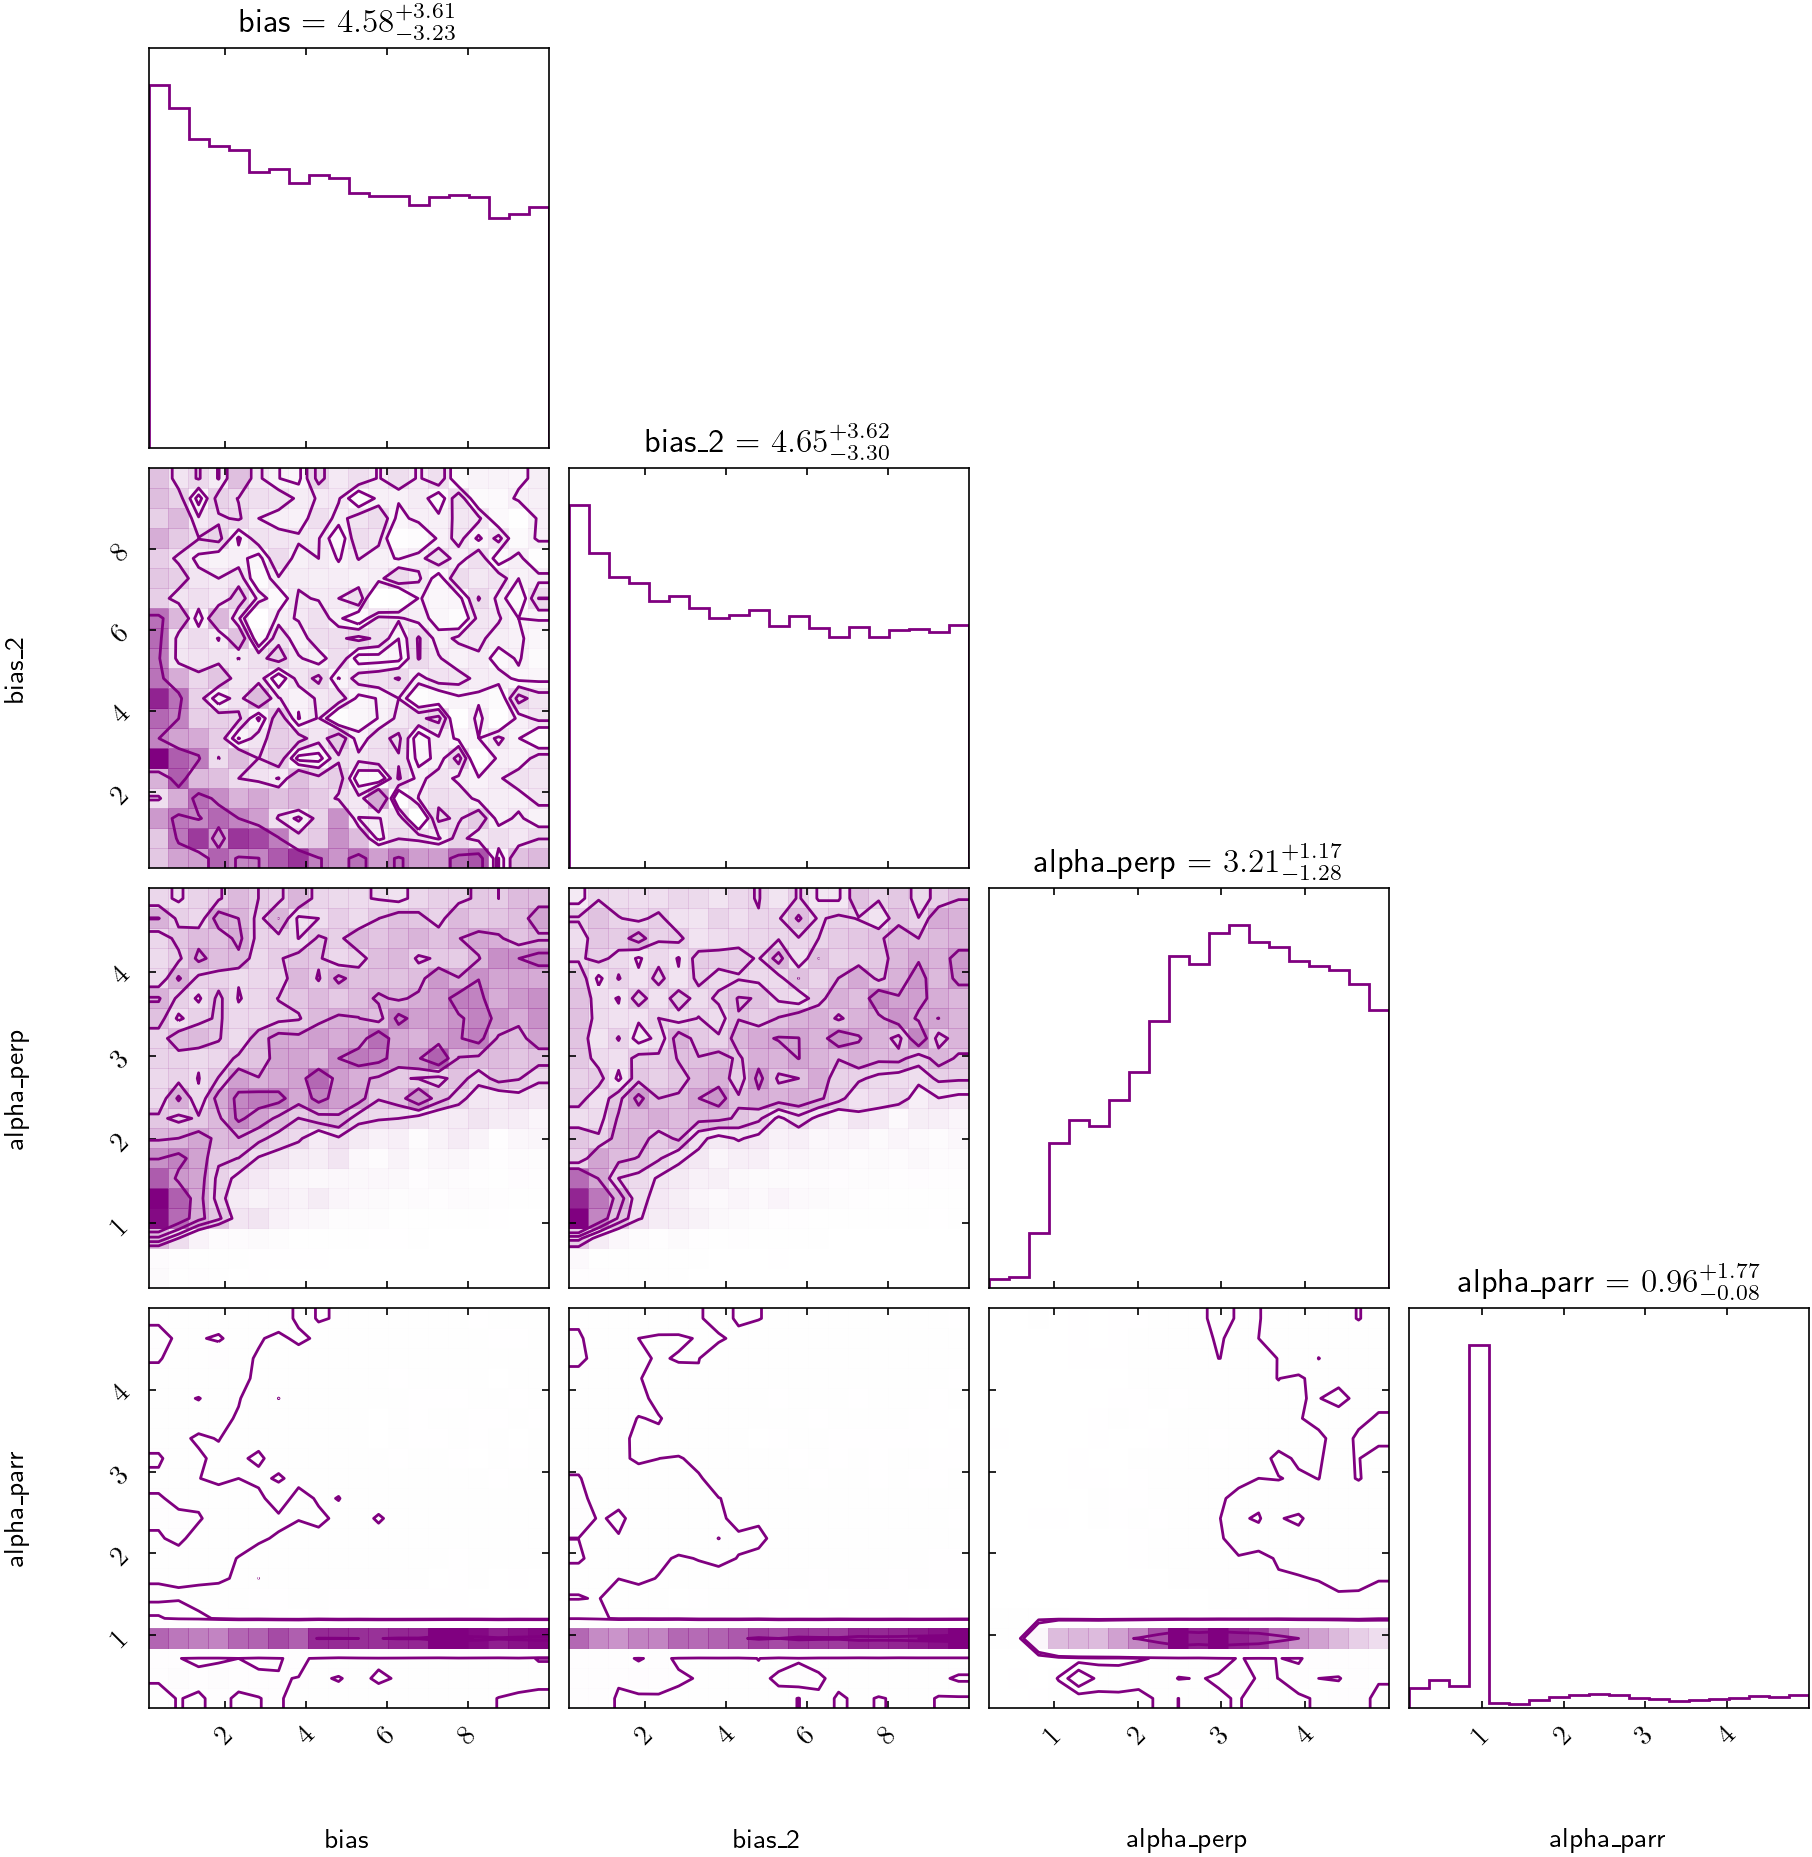

In [71]:
points, log_w, log_l = sampler.posterior()
corner.corner(
    points, weights=np.exp(log_w), bins=20, labels=prior.keys, color='purple',
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), show_titles=True,)
print("hello")